In [ ]:
import json

file_path = "/content/qwen_dataset.jsonl"

data = []

with open(file_path, "r") as f:
    for line in f:
        data.append(json.loads(line))

labels = [int(item["label"]) for item in data]

print("Total samples:", len(labels))
print("Vulnerable:", sum(labels))
print("Clean:", len(labels) - sum(labels))

Total samples: 4000
Vulnerable: 1869
Clean: 2131


In [3]:
from collections import Counter

print("Train:", Counter(dataset["train"]["label"]))
print("Test:", Counter(dataset["test"]["label"]))

Train: Counter({0: 1701, 1: 1499})
Test: Counter({0: 430, 1: 370})


In [ ]:
!pip install -q transformers datasets scikit-learn accelerate

import torch
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import torch
import pandas as pd
from datasets import load_dataset
from sklearn.metrics import precision_recall_curve, average_precision_score

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import logging

logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)
print("Libraries imported.")

raw_dataset = load_dataset('json', data_files='dataset.jsonl')

def format_labels(example):
    example['label'] = int(example['label'])
    return example

raw_dataset = raw_dataset.map(format_labels)

dataset = raw_dataset['train'].train_test_split(test_size=0.2, seed=42)
print(f"Train size: {len(dataset['train'])} | Test size: {len(dataset['test'])}")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary', zero_division=0
    )

    try:
        auroc = roc_auc_score(labels, probs)
        print('ok')
    except ValueError:
        print('error')
        auroc = 0.5

    return {
        'f1': f1,
        'auroc': auroc,
        'precision': precision,
        'recall': recall
    }

def run_baseline(model_checkpoint):
    print(f"STARTING BASELINE RUN: {model_checkpoint}")

    # Load Tokenizer & Model
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

    def tokenize_function(examples):
        return tokenizer(
            examples["func"],
            padding="max_length",
            truncation=True,
            max_length=512
        )

    print("Tokenizing dataset...")
    tokenized_datasets = dataset.map(tokenize_function, batched=True)


    training_args = TrainingArguments(
        # output_dir=f"./results_{model_checkpoint.replace('/', '_')}",
        eval_strategy="epoch",
        save_strategy="no",
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        num_train_epochs=3,
        weight_decay=0.01,
        fp16=True,
        report_to="none",
        logging_steps=50
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["test"],
        compute_metrics=compute_metrics,
    )

    print(f"Training {model_checkpoint}...")
    trainer.train()

    print(f"Evaluating {model_checkpoint}...")
    eval_results = trainer.evaluate()

    return eval_results

models_to_test = [
    "roberta-base",                  # NLP Baseline
    "microsoft/codebert-base",       # Syntax-Aware Code Baseline
    "microsoft/graphcodebert-base"   # Semantic-Aware Code Baseline
]

final_results = {}

for model_name in models_to_test:
    torch.cuda.empty_cache()

    res = run_baseline(model_name)

    final_results[model_name] = {
        'Eval F1': round(res['eval_f1'], 4),
        'Eval AUROC': round(res['eval_auroc'], 4),
        'Eval Precision': round(res['eval_precision'], 4),
        'Eval Recall': round(res['eval_recall'], 4),
        'Eval Loss': round(res['eval_loss'], 4)
    }

print(" BASELINE COMPARISON RESULTS ")
results_df = pd.DataFrame(final_results).T
display(results_df)

Libraries imported.


Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Train size: 3200 | Test size: 800
STARTING BASELINE RUN: roberta-base


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

...

ok
ok
ok
Evaluating microsoft/graphcodebert-base...


ok


Training Loss,Validation Loss,Epoch,F1,Auroc,Precision,Recall
0.610650,0.660568,3,0.513057,0.632637,0.594306,0.451351


 BASELINE COMPARISON RESULTS 


,Eval F1,Eval AUROC,Eval Precision,Eval Recall,Eval Loss
roberta-base,0.4704,0.5992,0.5765,0.3973,0.6765
microsoft/codebert-base,0.4281,0.6339,0.6398,0.3216,0.6368
microsoft/graphcodebert-base,0.5131,0.6326,0.5943,0.4514,0.6606


In [16]:
!rm -rf /content/trainer_output/

In [ ]:
!pip install -q optuna
import optuna
from transformers import EarlyStoppingCallback

print("HYPERPARAMETER TUNING FOR GRAPHCODEBERT")

torch.cuda.empty_cache()
gc.collect()

MODEL_CHECKPOINT = "microsoft/graphcodebert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def model_init():
    return AutoModelForSequenceClassification.from_pretrained(MODEL_CHECKPOINT, num_labels=2)

def tokenize_function(examples):
    return tokenizer(
        examples["func"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)

def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float(
            "learning_rate",
            5e-6,
            3e-5,
            log=True
        ),

        "per_device_train_batch_size": trial.suggest_categorical(
            "per_device_train_batch_size",
            [16, 32]
        ),

        "weight_decay": trial.suggest_float(
            "weight_decay",
            0.0,
            0.08
        ),

        "warmup_ratio": trial.suggest_float(
            "warmup_ratio",
            0.02,
            0.1
        )
    }

training_args = TrainingArguments(
    output_dir="./optuna_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    logging_strategy="steps",
    logging_steps=50,
    num_train_epochs=8,
    fp16=True,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    callbacks=[
      EarlyStoppingCallback(
          early_stopping_patience=2
      )
    ]
)

def compute_objective(metrics):
    return metrics["eval_f1"]

best_trial = trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=optuna_hp_space,
    n_trials=8,
    compute_objective=compute_objective
)

print("COMPLETE")
print(f"Best Trial ID: {best_trial.run_id}")
print("Best Hyperparameters:")
for key, value in best_trial.hyperparameters.items():
    print(f"  {key}: {value}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 19.5 MB/s eta 0:00:00
HYPERPARAMETER TUNING FOR GRAPHCODEBERT


Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

[transformers] The following layers were not sharded: roberta.embeddings.position_embeddings.weight, classifier.dense.bias, roberta.encoder.layer.*.attention.self.query.bias, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.layer.*.intermediate.dense.bias, classifier.out_proj.bias, roberta.embeddings.LayerNorm.bias, roberta.encoder.layer.*.attention.self.key.weight, roberta.encoder.layer.*.output.dense.weight, classifier.dense.weight, roberta.encoder.layer.*.attention.self.value.weight, roberta.embeddings.token_type_embeddings.weight, roberta.embeddings.LayerNorm.weight, roberta.encoder.layer.*.attention.output.LayerNorm.bias, roberta.encoder.layer.*.attention.self.value.bias, roberta.encoder.layer.*.attention.output.dense.weight, roberta.encoder.layer.*.output.LayerNorm.weight, roberta.encoder.layer.*.attention.self.query.weight, classifier.out_proj.weight, roberta.encoder.layer.*.attention.output.dense.bias, roberta.encoder.layer.*.attention.self.key.bias, r

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,F1,Auroc,Precision,Recall
1,0.687376,0.682146,0.211236,0.576851,0.626667,0.127027


ok


[I 2026-07-11 21:52:59,508] Trial 7 pruned. 


COMPLETE
Best Trial ID: 4
Best Hyperparameters:
  learning_rate: 2.677581169993068e-05
  per_device_train_batch_size: 16
  weight_decay: 0.06908867726772148
  warmup_ratio: 0.022561192296458643


In [6]:
MODEL_CHECKPOINT = "microsoft/graphcodebert-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=2
)

training_args = TrainingArguments(
    output_dir="./graphcodebert",

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    learning_rate=2.677581169993068e-05,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.06908867726772148,
    warmup_ratio=0.022561192296458643,

    num_train_epochs=4,
    fp16=True,

    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2)
    ]
)

trainer.train()

results = trainer.evaluate()

print("RESULTS: ")
for k, v in results.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

[transformers] The following layers were not sharded: roberta.embeddings.position_embeddings.weight, classifier.dense.bias, roberta.encoder.layer.*.attention.self.query.bias, roberta.encoder.layer.*.attention.output.LayerNorm.weight, roberta.encoder.layer.*.intermediate.dense.bias, classifier.out_proj.bias, roberta.embeddings.LayerNorm.bias, roberta.encoder.layer.*.attention.self.key.weight, roberta.encoder.layer.*.output.dense.weight, classifier.dense.weight, roberta.encoder.layer.*.attention.self.value.weight, roberta.embeddings.token_type_embeddings.weight, roberta.embeddings.LayerNorm.weight, roberta.encoder.layer.*.attention.output.LayerNorm.bias, roberta.encoder.layer.*.attention.self.value.bias, roberta.encoder.layer.*.attention.output.dense.weight, roberta.encoder.layer.*.output.LayerNorm.weight, roberta.encoder.layer.*.attention.self.query.weight, classifier.out_proj.weight, roberta.encoder.layer.*.attention.output.dense.bias, roberta.encoder.layer.*.attention.self.key.bias, r

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1,Auroc,Precision,Recall
1,0.689513,0.680836,0.526452,0.574466,0.503704,0.551351
2,0.655794,0.671095,0.558786,0.606879,0.524941,0.597297
3,0.575210,0.721693,0.594530,0.623702,0.530786,0.675676
4,0.494020,0.763381,0.497110,0.615022,0.534161,0.464865


ok


...

ok


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

ok


Training Loss,Validation Loss,Epoch,F1,Auroc,Precision,Recall
0.494020,0.721693,4,0.594530,0.623702,0.530786,0.675676


RESULTS: 
eval_loss: 0.7217
eval_f1: 0.5945
eval_auroc: 0.6237
eval_precision: 0.5308
eval_recall: 0.6757


In [ ]:
VULBERTA_CHECKPOINT = "claudios/VulBERTa-MLP-MVD"

print(f"Loading official VulBERTa tokenizer wrapper...")
tokenizer = AutoTokenizer.from_pretrained(VULBERTA_CHECKPOINT, trust_remote_code=True)

raw_dataset = load_dataset('json', data_files='dataset.jsonl')

def format_labels(example):
    example['label'] = int(example['label'])
    return example

raw_dataset = raw_dataset.map(format_labels)
dataset = raw_dataset['train'].train_test_split(test_size=0.2, seed=42)

def tokenize_function(examples):
    return tokenizer(
        examples["func"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

print("Mapping source code through VulBERTa tokenizer...")
tokenized_datasets = dataset.map(tokenize_function, batched=True)

Loading official VulBERTa tokenizer wrapper...


config.json:   0%|          | 0.00/2.57k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

tokenization_vulberta.py:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/claudios/VulBERTa-MLP-MVD:
- tokenization_vulberta.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Parameter 'function'=<function tokenize_function at 0x78683d0796c0> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Mapping source code through VulBERTa tokenizer...


Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary', zero_division=0
    )

    try:
        auroc = roc_auc_score(labels, probs)
    except ValueError:
        auroc = 0.5

    return {'f1': f1, 'auroc': auroc, 'precision': precision, 'recall': recall}

def model_init():
    return AutoModelForSequenceClassification.from_pretrained(
        VULBERTA_CHECKPOINT,
        num_labels=2,
        ignore_mismatched_sizes=True
    )

training_args = TrainingArguments(
    output_dir="./vulberta_project_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.05,
    num_train_epochs=5,
    fp16=True,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\nVULBERTA FINE-TUNING")
trainer.train()

print("\nEVALUATING METRICS")
eval_results = trainer.evaluate()
for key, value in eval_results.items():
    if key.startswith("eval_"):
        print(f"{key.replace('eval_', '').upper()}: {value:.4f}")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `41`.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: claudios/VulBERTa-MLP-MVD
Key                        | Status   |                                                                                        
---------------------------+----------+----------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([41, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([41]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.
[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `41`.



VULBERTA FINE-TUNING


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


EVALUATING METRICS


Training Loss,Validation Loss,Epoch,F1,Auroc,Precision,Recall
0.701869,0.702568,4,0.587618,0.515779,0.480274,0.756757


LOSS: 0.7026
F1: 0.5876
AUROC: 0.5158
PRECISION: 0.4803
RECALL: 0.7568


In [7]:
del trainer

In [ ]:
VULBERTA_CHECKPOINT = "claudios/VulBERTa-MLP-Devign"

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary', zero_division=0
    )

    try:
        auroc = roc_auc_score(labels, probs)
    except ValueError:
        auroc = 0.5

    return {'f1': f1, 'auroc': auroc, 'precision': precision, 'recall': recall}

def model_init():
    return AutoModelForSequenceClassification.from_pretrained(VULBERTA_CHECKPOINT, num_labels=2)

training_args = TrainingArguments(
    output_dir="./vulberta_optimized",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=8e-6, 
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.1, 
    num_train_epochs=5,
    fp16=True,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
    greater_is_better=False
)

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

print("\nVULBERTA FINE-TUNING")
trainer.train()

print("\nEVALUATING  METRICS")
eval_results = trainer.evaluate()
for key, value in eval_results.items():
    if key.startswith("eval_"):
        print(f"{key.replace('eval_', '').upper()}: {value:.4f}")

config.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


VULBERTA FINE-TUNING


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


EVALUATING  METRICS


Training Loss,Validation Loss,Epoch,F1,Auroc,Precision,Recall
No log,0.685653,2,0.238938,0.569133,0.658537,0.145946


LOSS: 0.6857
F1: 0.2389
AUROC: 0.5691
PRECISION: 0.6585
RECALL: 0.1459


Extracting hidden embeddings from VulBERTa...
Computing t-SNE projection...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


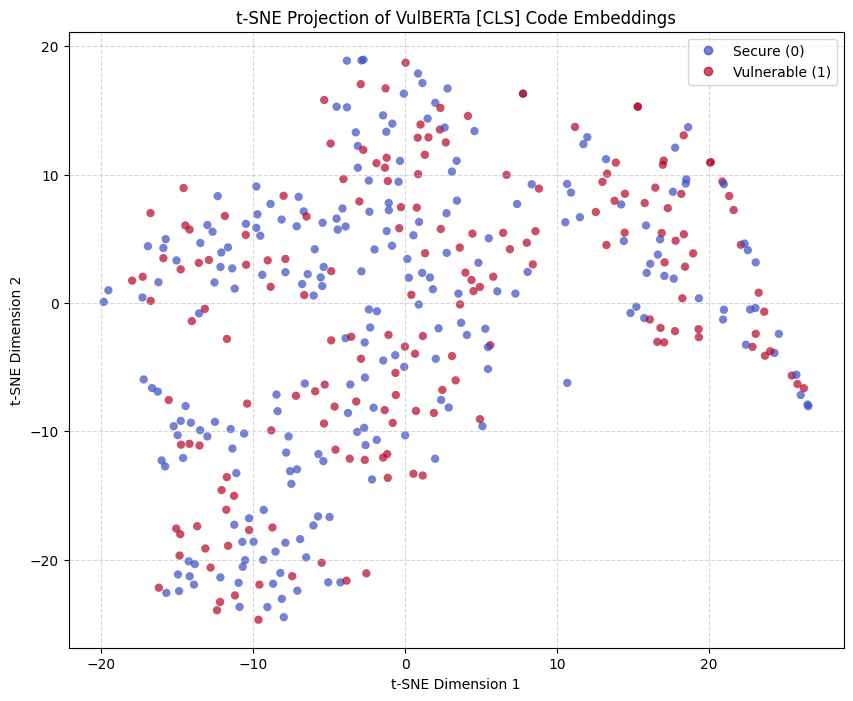

In [ ]:


print("Extracting hidden embeddings from VulBERTa...")
model = trainer.model.eval()
embeddings = []
true_labels = []

eval_subset = tokenized_datasets["test"].select(range(min(400, len(tokenized_datasets["test"]))))

for item in eval_subset:
    input_ids = torch.tensor([item['input_ids']]).cuda()
    attention_mask = torch.tensor([item['attention_mask']]).cuda()

    with torch.no_grad():
        outputs = model.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[0, 0, :].cpu().numpy()

    embeddings.append(cls_embedding)
    true_labels.append(item['label'])

embeddings = np.array(embeddings)
true_labels = np.array(true_labels)

print("Computing t-SNE projection...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=true_labels, cmap='coolwarm', alpha=0.7, edgecolors='none')
plt.legend(handles=scatter.legend_elements()[0], labels=['Secure (0)', 'Vulnerable (1)'])
plt.title('t-SNE Projection of VulBERTa [CLS] Code Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Generating prediction probabilities...


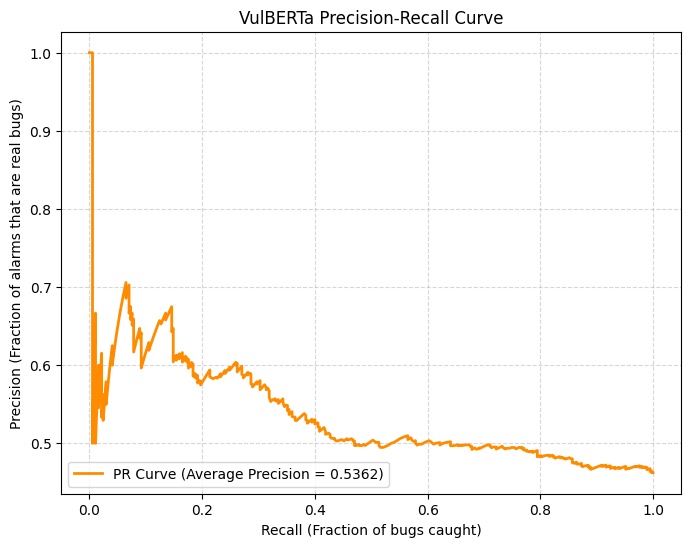

In [ ]:
print("Generating prediction probabilities...")
predictions = trainer.predict(tokenized_datasets["test"])
logits = predictions.predictions
y_true = predictions.label_ids
y_scores = torch.nn.functional.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
avg_precision = average_precision_score(y_true, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR Curve (Average Precision = {avg_precision:.4f})')
plt.xlabel('Recall (Fraction of bugs caught)')
plt.ylabel('Precision (Fraction of alarms that are real bugs)')
plt.title('VulBERTa Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Cleaned unique samples - Train: 3200 | Test: 800
Extracting code features from the hidden layers...
Projecting 768-D spaces to 2-D coordinates...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


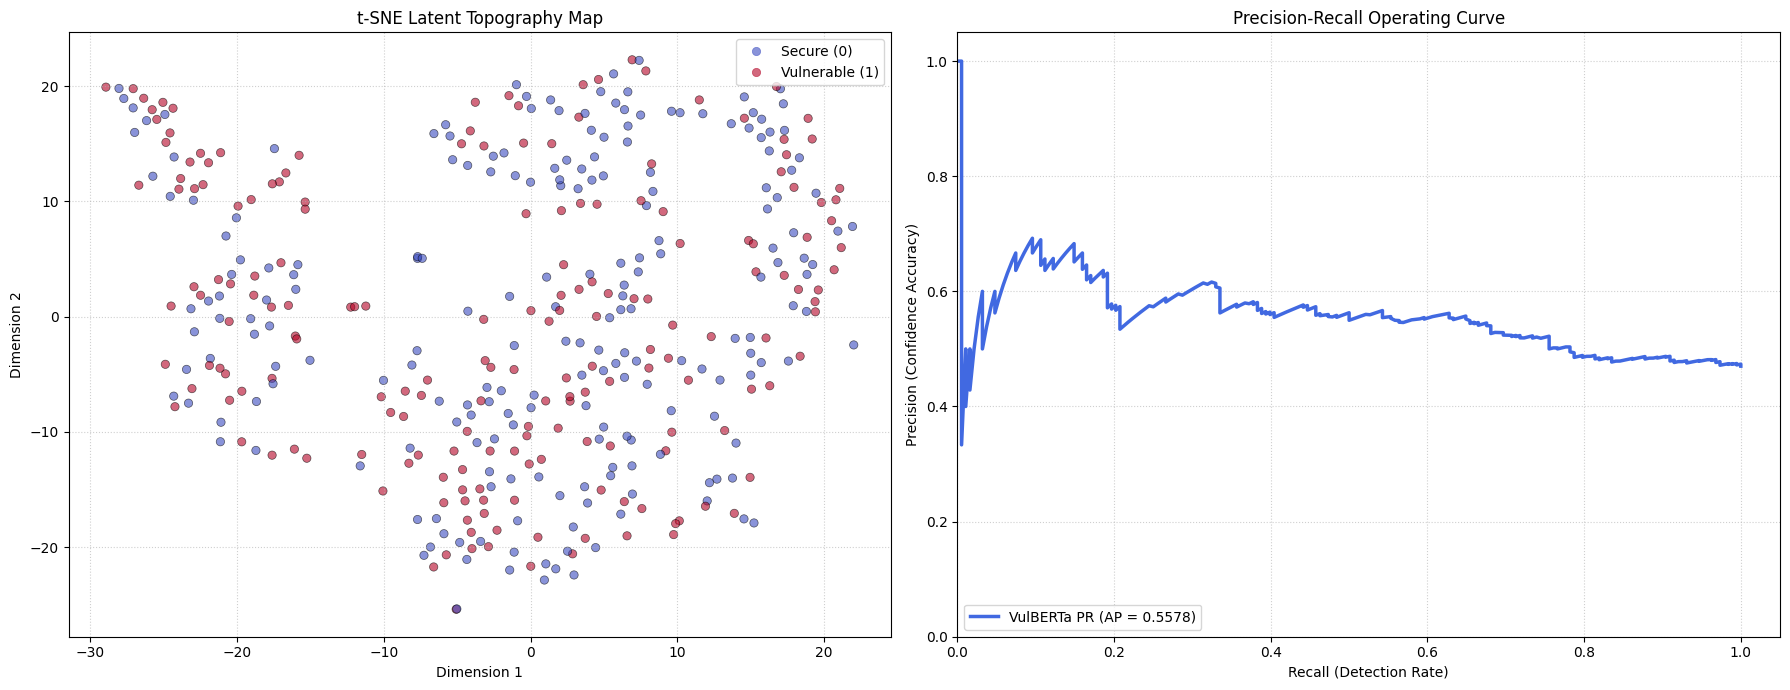

In [ ]:
df = pd.DataFrame(raw_dataset['train'])
df_cleaned = df.drop_duplicates(subset=['func']).copy()

train_df, test_df = train_test_split(df_cleaned, test_size=0.2, random_state=42)

print(f"Cleaned unique samples - Train: {len(train_df)} | Test: {len(test_df)}")

model = trainer.model.eval()
embeddings = []
y_true = []
y_scores = []

subset_df = test_df.head(400)

print("Extracting code features from the hidden layers...")
for _, row in subset_df.iterrows():
    inputs = tokenizer(row['func'], padding="max_length", truncation=True, max_length=512, return_tensors="pt")
    input_ids = inputs['input_ids'].cuda()
    attention_mask = inputs['attention_mask'].cuda()

    with torch.no_grad():
        outputs = model.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_state = outputs.last_hidden_state[0, 0, :].cpu().numpy()

        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        prob = torch.nn.functional.softmax(logits, dim=-1)[0, 1].cpu().item()

    embeddings.append(cls_state)
    y_scores.append(prob)
    y_true.append(int(row['label']))

embeddings = np.array(embeddings)
y_true = np.array(y_true)
y_scores = np.array(y_scores)

print("Projecting 768-D spaces to 2-D coordinates...")
tsne = TSNE(n_components=2, perplexity=25, n_iter=1000, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
scatter = ax1.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=y_true, cmap='coolwarm', alpha=0.6, edgecolors='black', linewidth=0.5)
ax1.set_title('t-SNE Latent Topography Map')
ax1.set_xlabel('Dimension 1')
ax1.set_ylabel('Dimension 2')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(handles=scatter.legend_elements()[0], labels=['Secure (0)', 'Vulnerable (1)'])

precision, recall, _ = precision_recall_curve(y_true, y_scores)
avg_p = average_precision_score(y_true, y_scores)
ax2.plot(recall, precision, color='royalblue', lw=2.5, label=f'VulBERTa PR (AP = {avg_p:.4f})')
ax2.set_xlabel('Recall (Detection Rate)')
ax2.set_ylabel('Precision (Confidence Accuracy)')
ax2.set_title('Precision-Recall Operating Curve')
ax2.set_xlim([0.0, 1.05])
ax2.set_ylim([0.0, 1.05])
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

In [ ]:
import re

def preprocess_code(code_str):
    # 1. Strip comments
    code_str = re.sub(r'//.*|/\*[\s\S]*?\*/', '', code_str)
    # 2. Normalize whitespace and newlines
    code_str = re.sub(r'\s+', ' ', code_str).strip()
    functions = ['pthread', 'mutex', 'lock', 'free', 'malloc', 'alloc', 'copy', 'memcpy', 'size']
    found_clues = [f for f in functions if f in code_str.lower()]

    return code_str, ", ".join(found_clues)

data = []
with open("qwen_dataset.jsonl", "r") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)
print(f"Original Dataset Size: {len(df)}")

cleaned_func = []
clues = []
for index, row in df.iterrows():
    c_func, clue = preprocess_code(row['func'])
    cleaned_func.append(c_func)
    clues.append(clue)

df['cleaned_func'] = cleaned_func
df['security_clues'] = clues

df_deduped = df.drop_duplicates(subset=['cleaned_func']).copy()
print(f"Dataset Size after Deduplication: {len(df_deduped)}")

df_deduped['input_text'] = "CLUES: " + df_deduped['security_clues'] + " | CODE: " + df_deduped['cleaned_func']

df_deduped[['input_text', 'label']].to_json("cleaned_dataset.json", orient="records", lines=True)
print("Advanced preprocessing complete! Cleaned dataset saved.")

Original Dataset Size: 4000
Dataset Size after Deduplication: 3999
Advanced preprocessing complete! Cleaned dataset saved.


In [ ]:
# Clear VRAM
torch.cuda.empty_cache()

VULBERTA_CHECKPOINT = "claudios/VulBERTa-MLP-Devign"
tokenizer = AutoTokenizer.from_pretrained(VULBERTA_CHECKPOINT)

raw_dataset = load_dataset('json', data_files='cleaned_dataset.json')

def format_labels(example):
    example['label'] = int(example['label'])
    return example

raw_dataset = raw_dataset.map(format_labels)
dataset = raw_dataset['train'].train_test_split(test_size=0.2, seed=42)

def tokenize_function(examples):
    return tokenizer(
        examples["input_text"],
        padding="max_length",
        truncation=True,
        max_length=512
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary', zero_division=0)
    try:
        auroc = roc_auc_score(labels, probs)
    except ValueError:
        auroc = 0.5
    return {'f1': f1, 'auroc': auroc, 'precision': precision, 'recall': recall}

def model_init():
    return AutoModelForSequenceClassification.from_pretrained(VULBERTA_CHECKPOINT, num_labels=2)

training_args = TrainingArguments(
    output_dir="./preprocessed_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.08,
    num_train_epochs=5,
    fp16=True,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False
)

trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()
print("\nEVALUATING METRICS")
print("="*50)
eval_results = trainer.evaluate()
for key, value in eval_results.items():
    if key.startswith("eval_"):
        print(f"{key.replace('eval_', '').upper()}: {value:.4f}")

tokenizer_config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.05M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/3999 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


EVALUATING METRICS


Training Loss,Validation Loss,Epoch,F1,Auroc,Precision,Recall
0.451503,0.505036,3,0.730506,0.830443,0.739612,0.721622


LOSS: 0.5050
F1: 0.7305
AUROC: 0.8304
PRECISION: 0.7396
RECALL: 0.7216


Extracting features from the hidden layers...
Projecting updated latent space to 2-D coordinates...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


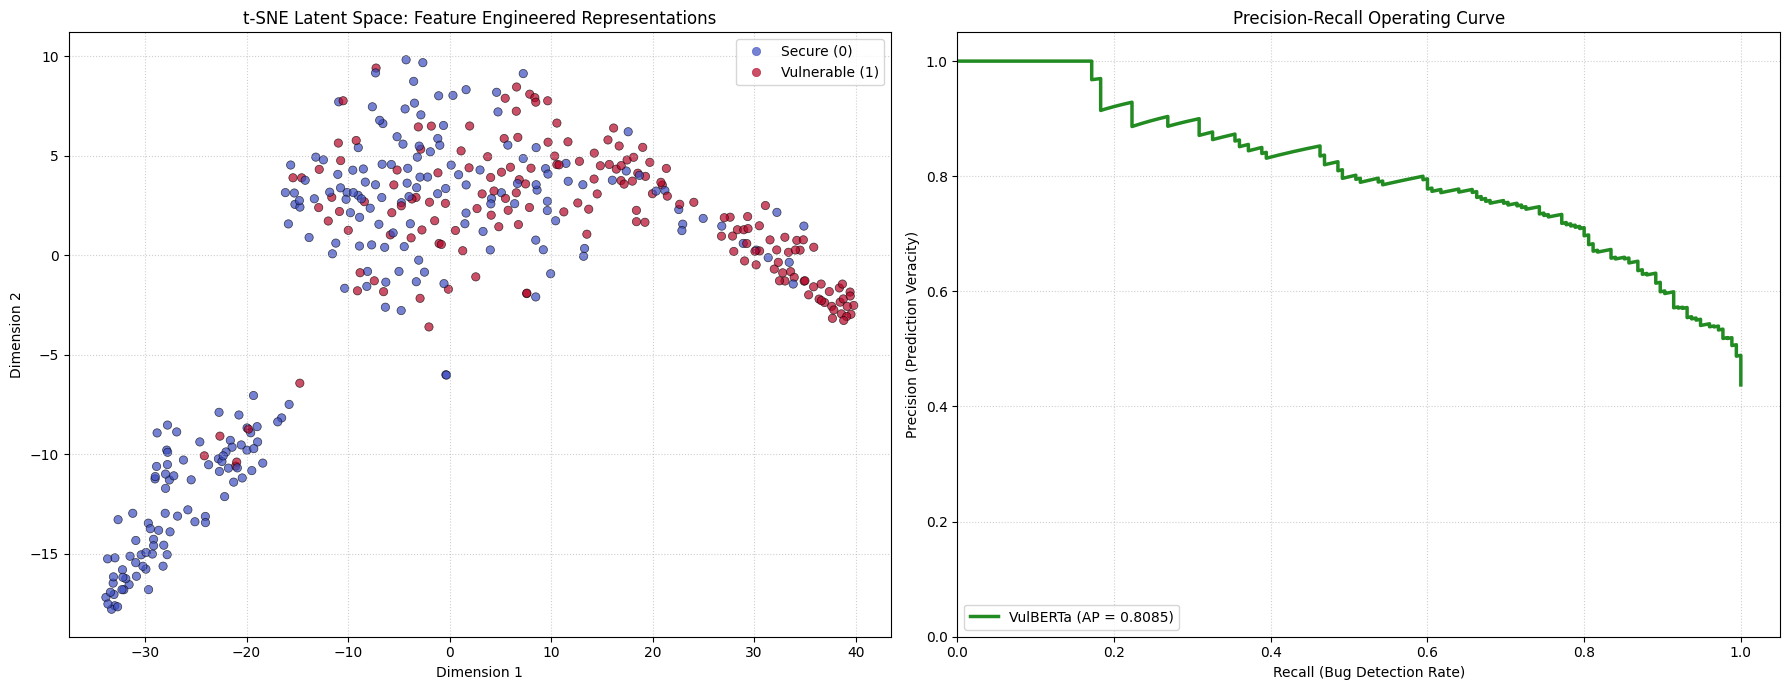

In [ ]:
model = trainer.model.eval()

embeddings = []
y_true = []
y_scores = []

eval_subset = tokenized_datasets["test"].select(range(min(400, len(tokenized_datasets["test"]))))

print("Extracting features from the hidden layers...")
for item in eval_subset:
    input_ids = torch.tensor([item['input_ids']]).cuda()
    attention_mask = torch.tensor([item['attention_mask']]).cuda()

    with torch.no_grad():
        outputs = model.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_state = outputs.last_hidden_state[0, 0, :].cpu().numpy()
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        prob = torch.nn.functional.softmax(logits, dim=-1)[0, 1].cpu().item()

    embeddings.append(cls_state)
    y_scores.append(prob)
    y_true.append(int(item['label']))

embeddings = np.array(embeddings)
y_true = np.array(y_true)
y_scores = np.array(y_scores)

print("Projecting updated latent space to 2-D coordinates...")
tsne = TSNE(n_components=2, perplexity=25, n_iter=1000, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

scatter = ax1.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=y_true,
    cmap='coolwarm',
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)
ax1.set_title('t-SNE Latent Space: Feature Engineered Representations')
ax1.set_xlabel('Dimension 1')
ax1.set_ylabel('Dimension 2')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(handles=scatter.legend_elements()[0], labels=['Secure (0)', 'Vulnerable (1)'])

precision, recall, _ = precision_recall_curve(y_true, y_scores)
avg_p = average_precision_score(y_true, y_scores)
ax2.plot(recall, precision, color='forestgreen', lw=2.5, label=f'VulBERTa (AP = {avg_p:.4f})')
ax2.set_xlabel('Recall (Bug Detection Rate)')
ax2.set_ylabel('Precision (Prediction Veracity)')
ax2.set_title('Precision-Recall Operating Curve')
ax2.set_xlim([0.0, 1.05])
ax2.set_ylim([0.0, 1.05])
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc="lower left")
plt.tight_layout()
plt.show()